In [1]:
from astropy.io import fits
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:

def image_grid(shape, recenter:bool = False):
    ny, nx = shape
    cy, cx = (0,0)
    if recenter:
        cy, cx = ny//2, nx//2
    x = np.arange(nx, dtype=float) - cx
    y = np.arange(ny, dtype=float) - cy
    X,Y = np.meshgrid(x, y)
    return X,Y

def get_photocenter(image,offset:bool=False):
    X,Y = image_grid(image.shape)
    qy = np.sum(Y * image) / np.sum(image)
    qx = np.sum(X * image) / np.sum(image)
    if offset:
        qy += 0.5
        qx += 0.5
    return qx,qy 

def get_frame_pupil_centers(frame,thr=0.3,xhalf=100,yhalf=120):
    Y,X = image_grid(frame.shape)
    ll = (X<=xhalf) * (Y<=yhalf)
    lr = (X>xhalf) * (Y<=yhalf)
    ul = (X<=xhalf) * (Y>yhalf)
    ur = (X>xhalf) * (Y>yhalf)
    centers = np.zeros([4,2])
    mask = (frame*ll > thr*np.nanmax(frame*ll)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[0,:] = np.array([qx,qy])
    mask = (frame*lr > thr*np.nanmax(frame*lr)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[1,:] = np.array([qx,qy])
    mask = (frame*ul > thr*np.nanmax(frame*ul)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[2,:] = np.array([qx,qy])
    mask = (frame*ur > thr*np.nanmax(frame*ur)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[3,:] = np.array([qx,qy])
    return centers

[[-34.82729433 -29.13370402]
 [-33.43978634  28.66589045]
 [ 34.51930124 -31.13193683]
 [ 33.74777943  31.59975039]]


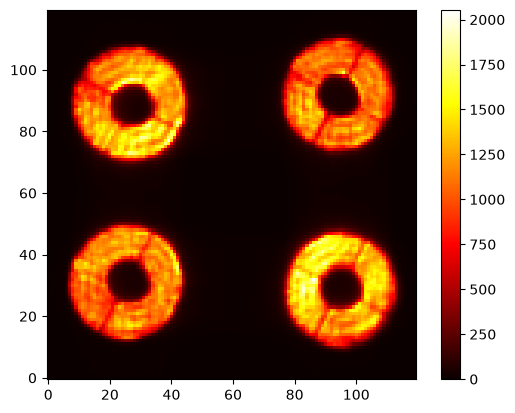

In [3]:
img = np.load('/raid1/mmenessini/calibration/EKARUS/data/OnSky_frame.npy')

ref_centers = get_frame_pupil_centers(img)
avg_center = np.mean(ref_centers,axis=0)
ref_dcenters = ref_centers-avg_center
print(ref_dcenters)

xmin = int(np.round(avg_center[0]))-60
xmax = int(np.round(avg_center[0]))+60
ymin = int(np.round(avg_center[1]))-60
ymax = int(np.round(avg_center[1]))+60

img = img[ymin:ymax,xmin:xmax]

plt.figure()
plt.imshow(img,origin='lower',cmap='hot')
plt.colorbar()

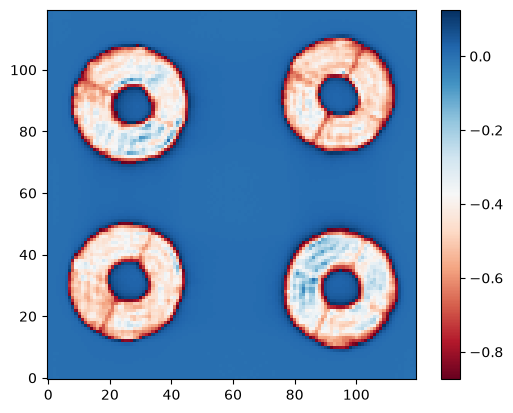

In [4]:
def two_level_thresholding(image, thr1 = 0.1, thr2 = 0.25):    
    min_val, max_val = float(np.min(image)), float(np.max(image))
    s1 = min_val + (max_val - min_val) * thr1

    thresh_img = image.copy()
    thresh_img[thresh_img < s1] = 0

    s2 = float(np.mean(thresh_img[thresh_img > 0])) * thr2
    mask = thresh_img >= s2
    return mask

est_mask = two_level_thresholding(img)
plt.figure()
plt.imshow(img/np.max(img)-est_mask,origin='lower',cmap='RdBu')
plt.colorbar()

[[ 0.06950804  0.2293815 ]
 [-0.08645872  0.21553327]
 [ 0.31379188 -0.20341512]
 [-0.2968412  -0.24149965]]


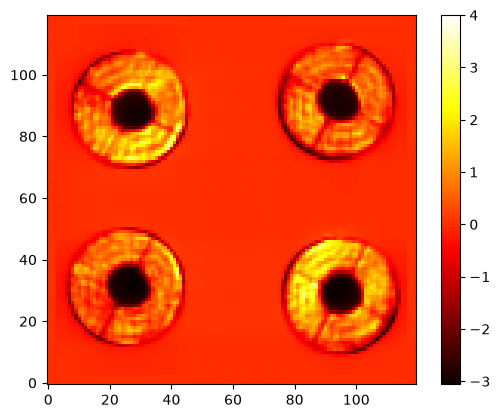

In [5]:
frame = fits.getdata('/raid1/mmenessini/results/EKARUS/frame.fits')[0,60:180,60:180]

centers = get_frame_pupil_centers(frame,xhalf=60,yhalf=60)
dcenters = centers-np.mean(centers,axis=0)
tilt_coeffs = ref_dcenters.T/30
print(dcenters-ref_dcenters)

plt.figure()
plt.imshow(frame,origin='lower',cmap='hot',vmax=200)
plt.imshow(img/np.mean(img)-frame/np.mean(frame),origin='lower',cmap='hot')
plt.colorbar()

In [6]:
from specula.mmlib.utils import get_pupil_mask

sky_pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onsky.fits')[60:180,60:180]


2026-08-07 08:25:17,867 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-08-07 08:25:18,000 [INFO]: [specula]: Default device is GPU number 0


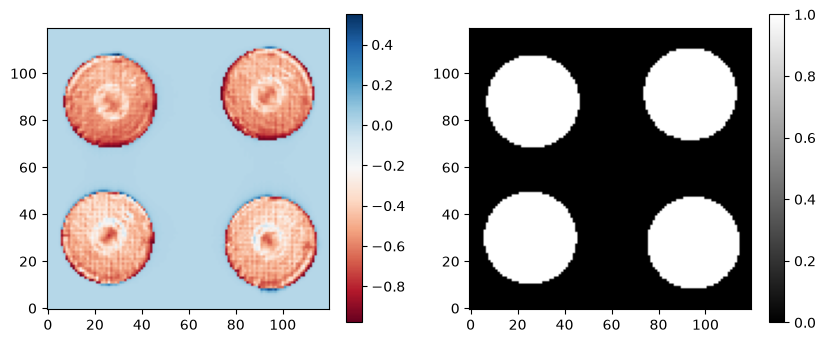

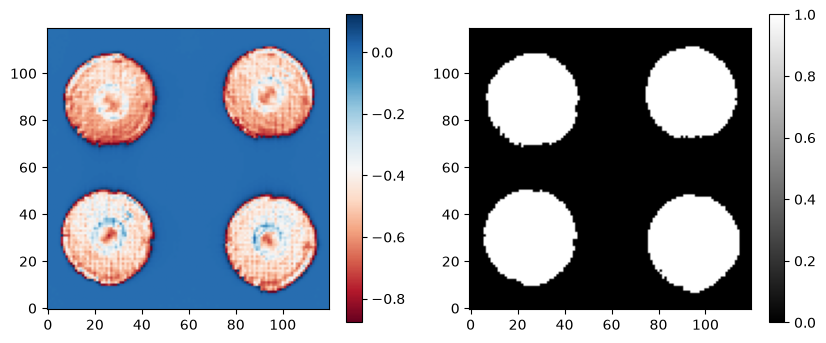

In [7]:
im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260802_233704.fits')
imold = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260731_233429.fits')
# im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260729_122235.fits')
pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')[60:180,60:180]

imframe = im[:,290].reshape([240,240])
imframe = np.std(im,axis=1).reshape([240,240])

ref_centers = get_frame_pupil_centers(imframe)
savg_center = np.mean(ref_centers,axis=0)

xsmin = int(np.round(savg_center[0]))-60
xsmax = int(np.round(savg_center[0]))+60
ysmin = int(np.round(savg_center[1]))-60
ysmax = int(np.round(savg_center[1]))+60

frimg = imframe[ysmin:ysmax,xsmin:xsmax]

# np.save('/raid1/mmenessini/calibration/EKARUS/data/OnBench_frame.npy',imframe)

thr_mask = two_level_thresholding(frimg)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(frimg/np.max(frimg)-pyr_mask,origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(pyr_mask,origin='lower',cmap='gray')
plt.colorbar()
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(frimg/np.max(frimg)-thr_mask,origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(thr_mask,origin='lower',cmap='gray')
plt.colorbar()

In [8]:
# iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/reordered_unobs_DM468_ifunc.fits')
# pupil_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/reordered_unobs_DM468_160pixels.fits')).astype(bool)

# # from scipy.ndimage import rotate
# # idx_mask = np.where(pupil_mask)

# # rot_deg = 180
# # flip_iff = np.zeros_like(iffs)
# # for i in range(iffs.shape[1]):
# #     mode_img = np.zeros(pupil_mask.shape)
# #     mode_img[idx_mask] = iffs[:,i]
# #     mode_img = np.reshape(mode_img,pupil_mask.shape)
# #     flip_img = mode_img[:,::-1]
# #     # flip_iff[:,i] = flip_img[idx_mask]
# #     rot_img = rotate(flip_img,angle=rot_deg,reshape=False)
# #     flip_iff[:,i] = rot_img[idx_mask]

# from specula.data_objects.ifunc import IFunc    
# ifunc_obj = IFunc(
#         ifunc=flip_iff.T,
#         mask=(pupil_mask).astype(np.uint8) # bin_pup_mask
#     )
# ifunc_obj.save('/raid1/mmenessini/calibration/EKARUS/ifunc/reordered_unobs_DM468_ifunc.fits', overwrite=True)

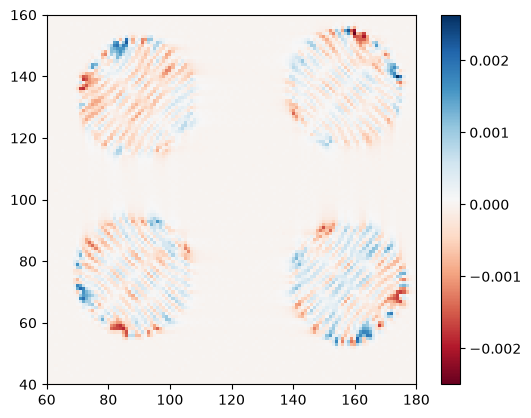

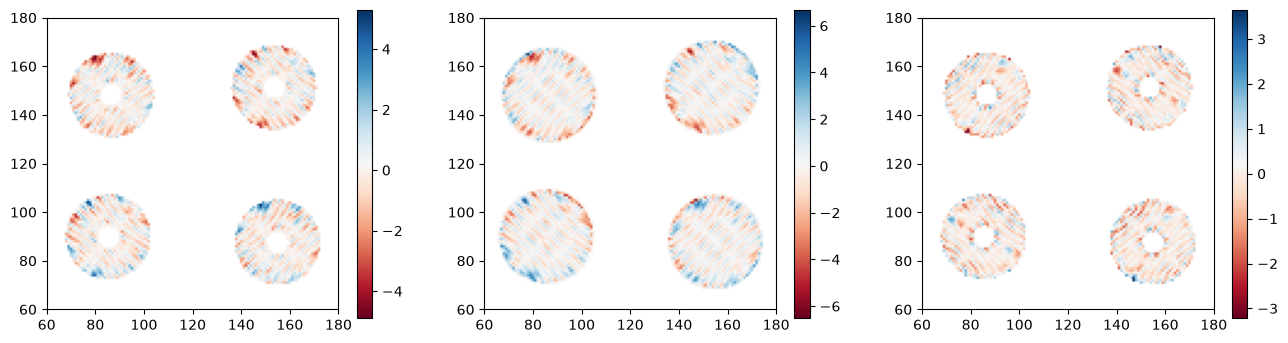

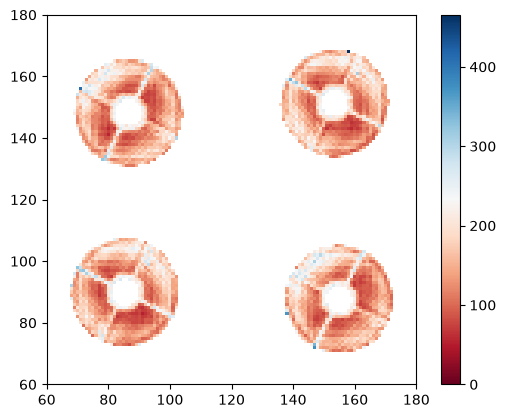

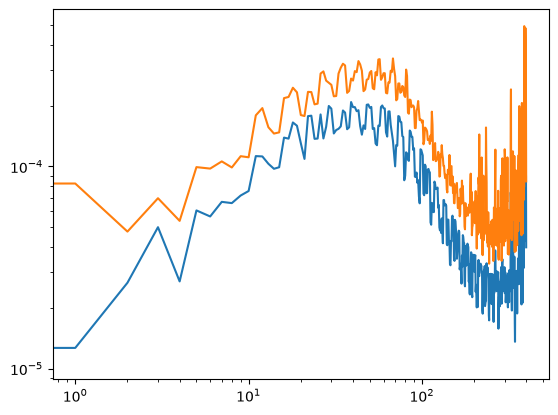

In [34]:
rMod = 5
skyim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_onsky_dm468_im.fits')
skyim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_onsky_measIF_dm468_im.fits')
benchim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_onbench_dm468_im.fits')
benchim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_onbench_measIF_dm468_im.fits')
# benchim = fits.getdata('/raid1/mmenessini/calibration/EKARUS/im/pyr3.0_onbench_measIF_bestshift_dm468_im.fits')
pup_hdu = fits.open('/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onsky.fits')
pup_ids_sky = pup_hdu[1].data
pup_hdu = fits.open('/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')
pup_ids_bench = pup_hdu[1].data

sky_pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onsky.fits')
pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')

j = 399
npix = 240
diff = np.zeros([npix,npix])
fimg_sky = np.zeros([npix,npix])
fimg_bench = np.zeros([npix,npix])
im_onbench_crop = np.zeros_like(skyim)
for i in range(400):
    rtot = 0
    for k in range(4):
        valid_ids = pup_ids_bench[:,k] != -1
        len_ids = np.sum(valid_ids)
        np.put(fimg_bench, pup_ids_bench[valid_ids,k], benchim[rtot:rtot+len_ids,i])
        rtot += len_ids
    rtot = 0
    for k in range(4):
        valid_ids = pup_ids_sky[:,k] != -1
        len_ids = np.sum(valid_ids)
        np.put(fimg_sky, pup_ids_sky[valid_ids,k], skyim[rtot:rtot+len_ids,i])
        im_onbench_crop[skyim.shape[0]//4:skyim.shape[0]//4+len_ids,i] = fimg_bench.flatten()[pup_ids_sky[valid_ids,k]]
        rtot += len_ids
    sky2d = fimg_sky.reshape([npix,npix])
    bench2d = fimg_bench.reshape([npix,npix])
    if i == j:
        f2d_sky = sky2d/np.std(sky2d[sky_pyr_mask])
        f2d_bench = bench2d/np.std(bench2d[sky_pyr_mask])
    diff += abs(sky2d/np.std(sky2d[sky_pyr_mask])-bench2d/np.std(bench2d[sky_pyr_mask]))

# from specula.data_objects.intmat import Intmat
# im_obj = Intmat(intmat=im_onbench_crop)
# im_obj.save('/raid1/mmenessini/calibration/EKARUS/im/pyr5.0_onbench_crop_measIF_im.fits',overwrite=True)

plt.figure()
plt.imshow(imold[:,j].reshape([240,240]),origin='lower',cmap='RdBu')
plt.colorbar()
plt.xlim([60,180])
plt.ylim([40,160])

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(f2d_sky,mask=1-sky_pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.xlim([60,180])
plt.ylim([60,180])
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(f2d_bench,mask=1-pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.xlim([60,180])
plt.ylim([60,180])
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(f2d_bench-f2d_sky,mask=1-sky_pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.xlim([60,180])
plt.ylim([60,180])

plt.figure()
plt.imshow(np.ma.masked_array(diff,mask=1-sky_pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.xlim([60,180])
plt.ylim([60,180])

plt.figure()
plt.loglog(np.diag(skyim.T @ skyim))
# plt.loglog(np.diag(im_onbench_crop.T @ im_onbench_crop))
plt.loglog(np.diag(benchim.T @ benchim))
# plt.loglog(np.diag(imold.T @ imold))
# plt.loglog(np.diag(im.T @ im))

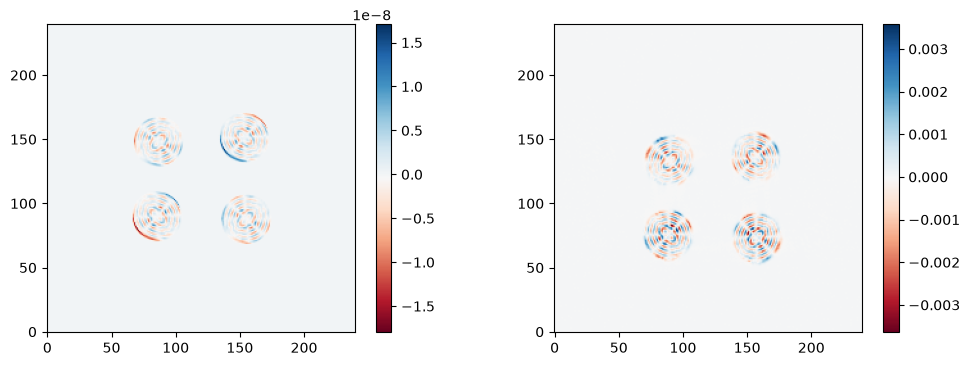

In [10]:
synim = fits.getdata('/raid1/mmenessini/calibration/EKARUS/im/pyr5.0_dm468_onbench_synim.fits')
pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')
pup_hdu = fits.open('/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')
pup_ids = pup_hdu[1].data

j = 200
npix = 240
fimg = np.zeros([npix,npix])
rtot = 0
for i in range(4):
    valid_ids = pup_ids[:,i] != -1
    len_ids = np.sum(valid_ids)
    np.put(fimg, pup_ids[valid_ids,i], synim[rtot:rtot+len_ids,j])
    rtot += len_ids
# fimg[pyr_mask] = synim[:,j]
f2d = fimg.reshape([npix,npix])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(f2d,origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(im[:,j].reshape([240,240]),origin='lower',cmap='RdBu')
plt.colorbar()

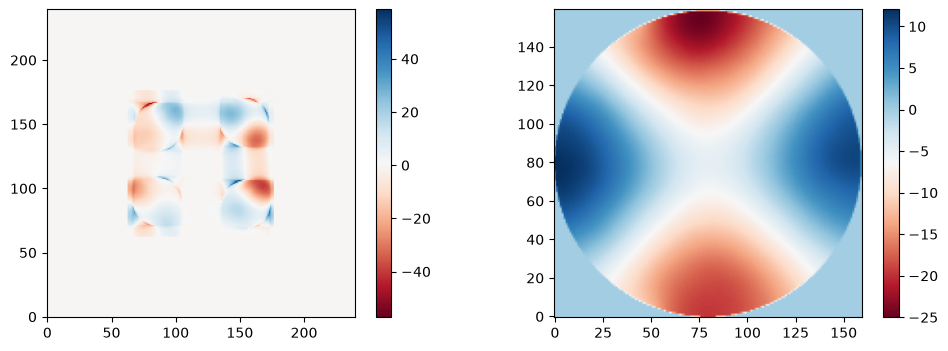

In [11]:
frames = fits.getdata('/raid1/mmenessini/results/EKARUS/calib_frame.fits')
phases = fits.getdata('/raid1/mmenessini/results/EKARUS/dm_ef.fits')[:,1,:,:]

# mask = np.sum(abs(phases),axis=0)==0
# print(mask.shape,phases.shape)
# rmsvec = np.zeros(300)
# for j in range(300):
#     phi = phases[j]
#     rmsvec[j] = np.std(phi[~mask])

# plt.figure()
# plt.plot(rmsvec)

idx = 2
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(frames[1+idx*2]-frames[0+idx*2],origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(phases[1+idx*2]-phases[0+idx*2],origin='lower',cmap='RdBu')
plt.colorbar()

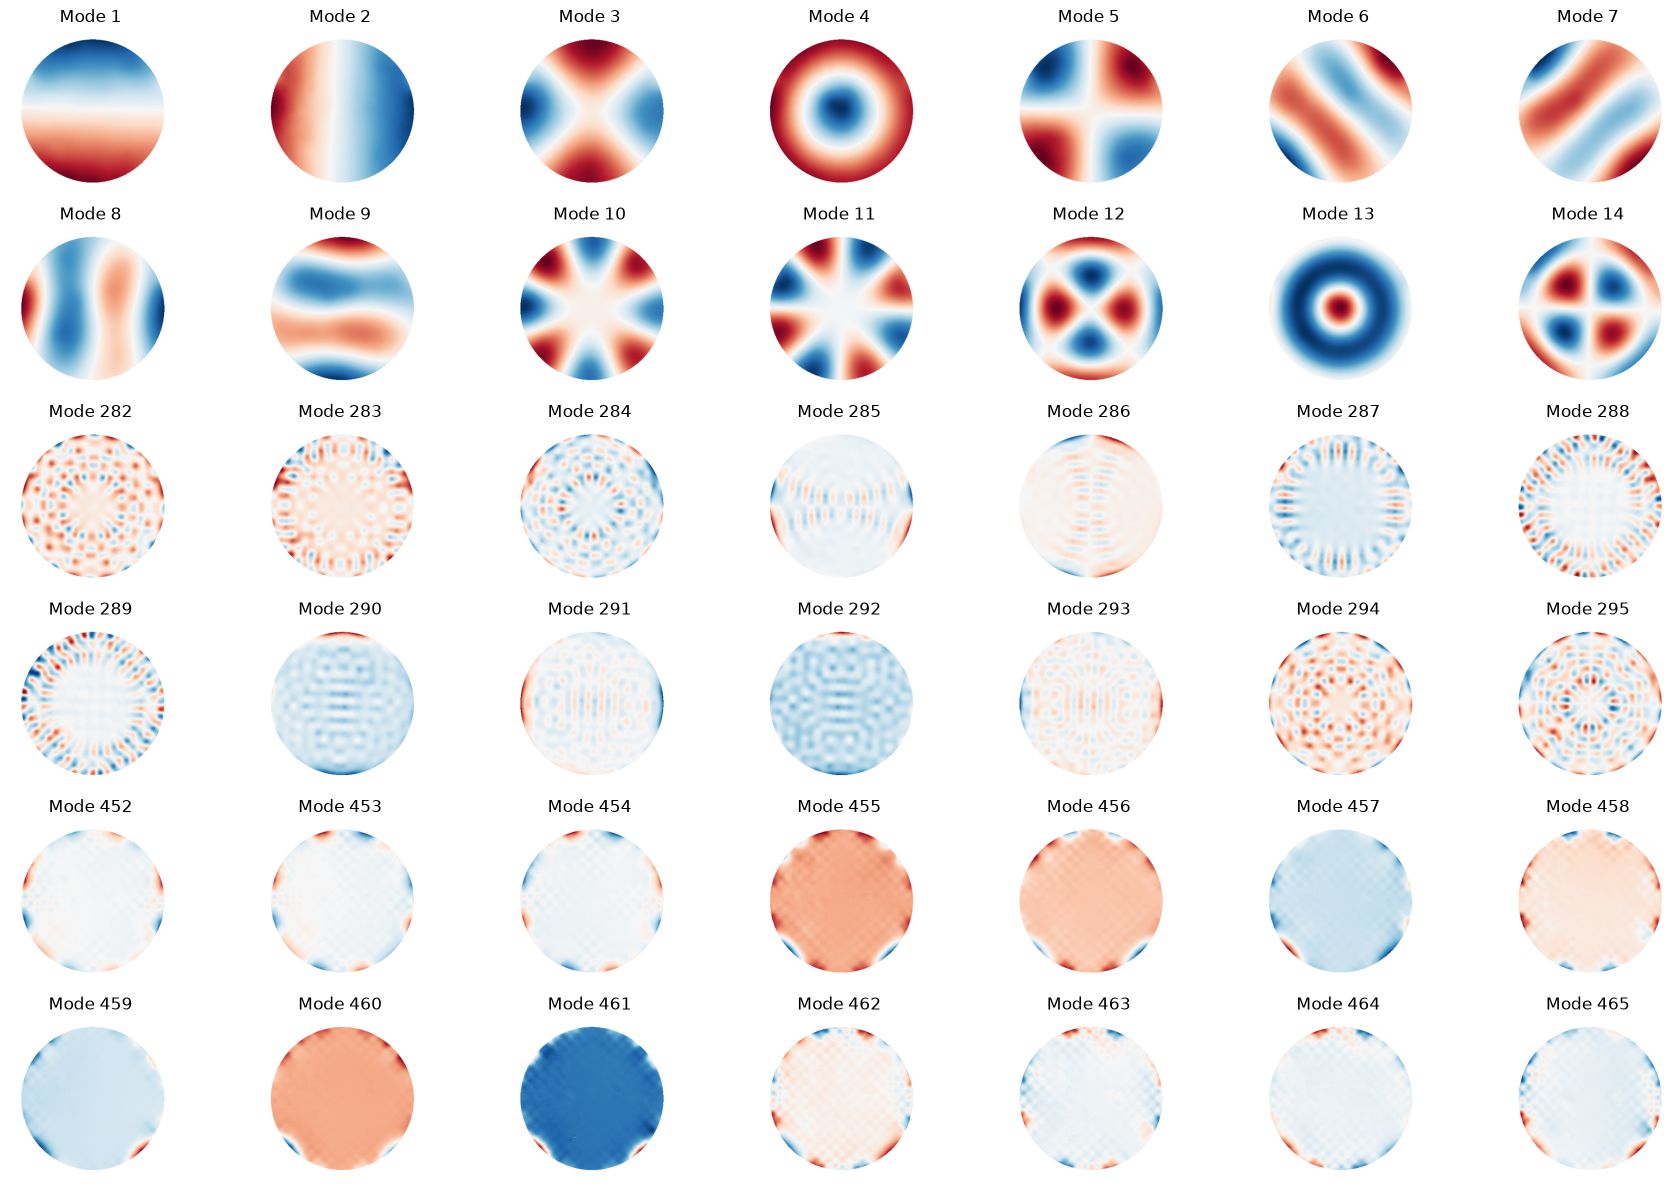

In [17]:
# m2c = np.load('/raid1/mmenessini/calibration/EKARUS/m2c/M2C_KL_OOPAO_central_obstruction.npy')
iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/reordered_IFs.fits')
pupil_mask = (1-fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IFmask.fits')).astype(bool)
m2c = np.load('/raid1/mmenessini/calibration/EKARUS/m2c/M2C_KL_OOPAO_synthetic.npy')
# iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/simul_DM468_ifunc.fits')
# pupil_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/simul_DM468_160pixels.fits')).astype(bool)
# m2c = fits.getdata('/raid1/mmenessini/calibration/EKARUS/m2c/simul_unobs_DM468_m2c.fits')
# iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/simul_unobs_DM468_ifunc.fits')
# pupil_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/simul_unobs_DM468_160pixels.fits')).astype(bool)

kl_basis = (iffs @ m2c).T #iffs.T #
max_modes = 42
mode_display = np.zeros((max_modes, pupil_mask.shape[0], pupil_mask.shape[1]))
idx_mask = np.where(pupil_mask)
mode_ids = np.zeros(max_modes,dtype=int)

for i in range(max_modes//3):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = i+1
    mode_img[idx_mask] = kl_basis[i]
    mode_display[i] = mode_img
for i in range(max_modes//3,2*max_modes//3):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = kl_basis.shape[0]//1.5-max_modes+i
    mode_img[idx_mask] = kl_basis[mode_ids[i]]
    mode_display[i] = mode_img
for i in range(2*max_modes//3,max_modes):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = kl_basis.shape[0]-max_modes+i
    mode_img[idx_mask] = kl_basis[mode_ids[i]]
    mode_display[i] = mode_img

# Plot the reshaped modes
n_rows = 6 #int(np.round(np.sqrt(max_modes)))
n_cols = 7 #int(np.ceil(max_modes / n_rows))
plt.figure(figsize=(18, 12))
for i in range(max_modes):
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(np.ma.masked_array(mode_display[i],mask=1-pupil_mask),origin='lower',cmap='RdBu')
    plt.title(f'Mode {mode_ids[i]}')
    plt.axis('off')
plt.tight_layout()

0.08136733488353311 0.018753656107868402 0.08054101971205352 1.0018212413299823


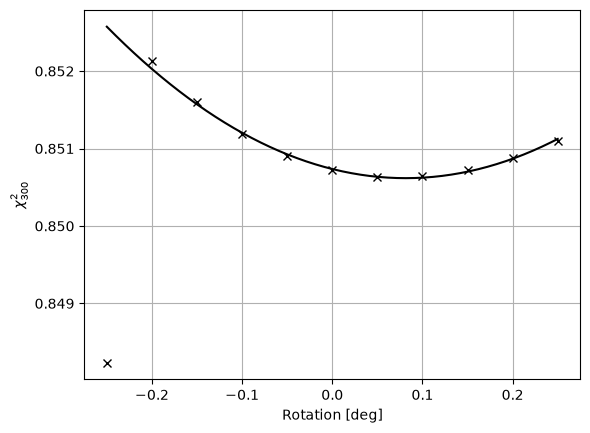

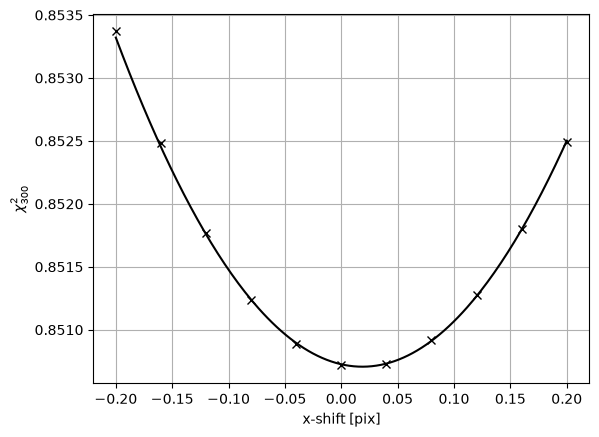

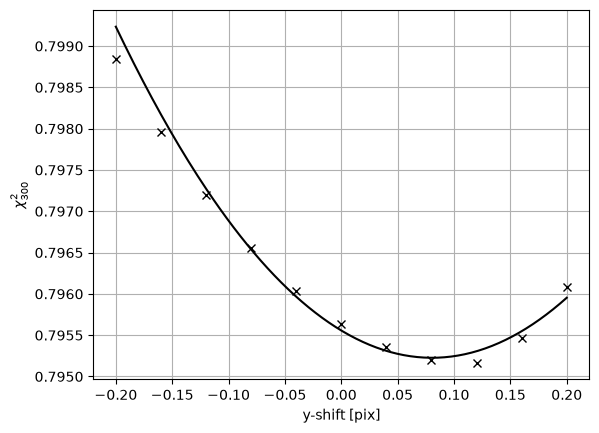

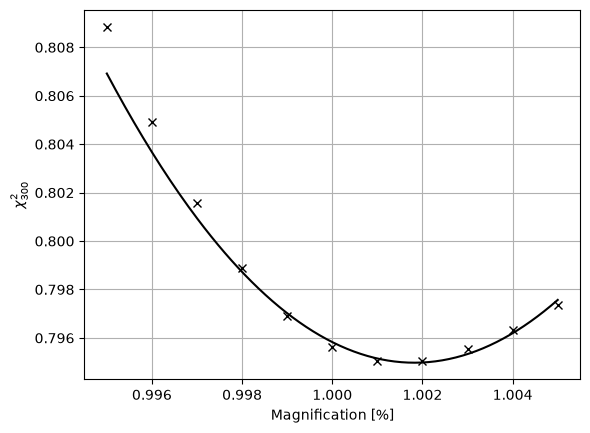

In [13]:
# # rotvec = np.linspace(-5.0,5.0,21)
# # shiftvec = np.linspace(-1.5,1.5,21)
# # mags = np.linspace(-0.05,0.05,11)+1.0
# rotvec = np.linspace(-2.0,2.0,21)
# shiftvec = np.linspace(-0.5,0.5,11)
# dmags = np.linspace(-0.02,0.02,11)
# dRot = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it1_deltaRot0.19_300modes_metrics.fits')**2,axis=1))
# dshX = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it1_deltaShiftX0.09_300modes_metrics.fits')**2,axis=1))
# dshY = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it1_deltaShiftY0.09_300modes_metrics.fits')**2,axis=1))
# dMag = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it1_deltaMag0.36_300modes_metrics.fits')**2,axis=1))
# rotvec = np.linspace(-1.0,1.0,21)
# shiftvec = np.linspace(-0.25,0.25,11)
# dmags = np.linspace(-0.01,0.01,11)
# dRot = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it2_deltaRot0.10_300modes_metrics.fits')**2,axis=1))
# dshX = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it2_deltaShiftX0.05_300modes_metrics.fits')**2,axis=1))
# dshY = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it2_deltaShiftY0.05_300modes_metrics.fits')**2,axis=1))
# dMag = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it2_deltaMag0.18_300modes_metrics.fits')**2,axis=1))
rotvec = np.linspace(-0.25,0.25,11)
shiftvec = np.linspace(-0.2,0.2,11)
dmags = np.linspace(-0.005,0.005,11)
dRot = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it3_deltaRot0.05_300modes_metrics.fits')**2,axis=1))
dshX = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it3_deltaShiftX0.04_300modes_metrics.fits')**2,axis=1))
dshY = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it3_deltaShiftY0.04_300modes_metrics.fits')**2,axis=1))
dMag = np.sqrt(np.sum(fits.getdata('/raid1/mmenessini/results/EKARUS/misreg_csv/it3_deltaMag0.09_300modes_metrics.fits')**2,axis=1))


prot = np.polyfit(rotvec[2:],dRot[2:],2) #
x = np.linspace(np.min(rotvec),np.max(rotvec),200)
plt.figure()
plt.plot(rotvec,dRot,'x',c='k') #[skip:-skip-3]
plt.plot(x,np.polyval(prot,x),c='k')
plt.xlabel('Rotation [deg]')
plt.ylabel(r'$\chi_{300}^2$')
plt.grid()

pshfX = np.polyfit(shiftvec[2:],dshX[2:],2) #
x = np.linspace(np.min(shiftvec),np.max(shiftvec),200)
plt.figure()
plt.plot(shiftvec,dshX,'x',c='k') #[skip:-skip-3]
plt.plot(x,np.polyval(pshfX,x),c='k')
plt.xlabel('x-shift [pix]')
plt.ylabel(r'$\chi_{300}^2$')
plt.grid()

pshfY = np.polyfit(shiftvec[2:],dshY[2:],2) #
plt.figure()
plt.plot(shiftvec,dshY,'x',c='k') #[skip:-skip-3]
plt.plot(x,np.polyval(pshfY,x),c='k')
plt.xlabel('y-shift [pix]')
plt.ylabel(r'$\chi_{300}^2$')
plt.grid()

pMag = np.polyfit(dmags[3:]+1,dMag[3:],2) #
x = np.linspace(np.min(dmags),np.max(dmags),200)+1
plt.figure()
plt.plot(dmags+1,dMag,'x',c='k') #[skip:-skip-3]
plt.plot(x,np.polyval(pMag,x),c='k')
plt.xlabel('Magnification [%]')
plt.ylabel(r'$\chi_{300}^2$')
plt.grid()


print(prot[1]/(-2*prot[0]),pshfX[1]/(-2*pshfX[0]),pshfY[1]/(-2*pshfY[0]),pMag[1]/(-2*pMag[0]))

In [14]:
# act_ids = np.argmax(iffs,axis=0)
# X,Y = image_grid(pupil_mask.shape)
# xx = X[pupil_mask]
# yy = Y[pupil_mask]
# xacts = xx[act_ids.astype(int)]
# yacts = yy[act_ids.astype(int)]

# dm468Map = np.array([
#     [0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
#     [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
#     [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
#     [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
#     [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
#     [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
#     [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
#     [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
#     [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
#     [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
#     [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
#     [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
#     [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
#     [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
#     [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
#     [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
#     [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
#     [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
#     [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
#     [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
#     [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
#     [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
#     [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
#     [0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0]
#  ]
# )

# yact2d = np.zeros(dm468Map.shape)
# yact2d[dm468Map.astype(bool)] = yacts
# yact2d = yact2d.reshape(dm468Map.shape)

# xact2d = np.zeros(dm468Map.shape)
# xact2d[dm468Map.astype(bool)] = xacts
# xact2d = xact2d.reshape(dm468Map.shape)

# actIds = np.arange(468)
# act_ids2d = np.zeros(dm468Map.shape)
# act_ids2d[dm468Map.astype(bool)] = actIds
# act_ids2d = act_ids2d.reshape(dm468Map.shape)

# descramble2d = act_ids2d.copy()
# for i in range(12,24):
#     xcoords = xact2d[i,:]
#     ids = act_ids2d[i,:] > 0
#     sortids = np.argsort(xcoords[ids.astype(bool)])
#     print(sortids)
#     descramble2d[i,ids] = descramble2d[i,ids][sortids]

# descramble = (descramble2d[dm468Map.astype(bool)]).astype(int)

# plt.figure()
# plt.subplot(1,2,1)
# plt.imshow(yact2d)
# plt.subplot(1,2,2)
# plt.imshow(xact2d)

# dyact2d = np.zeros(dm468Map.shape)
# dyact2d[dm468Map.astype(bool)] = yacts[descramble]
# dyact2d = dyact2d.reshape(dm468Map.shape)

# dxact2d = np.zeros(dm468Map.shape)
# dxact2d[dm468Map.astype(bool)] = xacts[descramble]
# dxact2d = dxact2d.reshape(dm468Map.shape)

# plt.figure()
# plt.subplot(1,2,1)
# plt.imshow(dyact2d)
# plt.subplot(1,2,2)
# plt.imshow(dxact2d)

# # fits.writeto('/raid1/mmenessini/calibration/EKARUS/data/reordered_IFs.fits',iffs[:,descramble],overwrite=True)